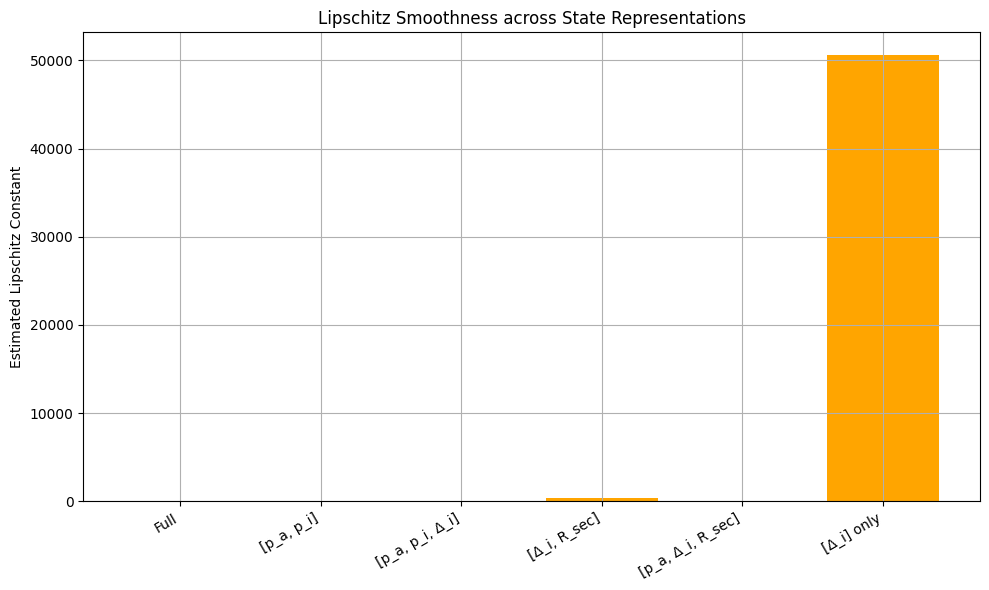

         State Combo  Dim  Estimated Lipschitz
0               Full   11             0.562766
1         [p_a, p_i]    4             0.873886
2    [p_a, p_i, Δ_i]    5             0.864434
3       [Δ_i, R_sec]    2           391.168015
4  [p_a, Δ_i, R_sec]    4            10.130721
5         [Δ_i] only    1         50637.326853


In [ ]:
import numpy as np
from itertools import combinations
import pandas as pd
import matplotlib.pyplot as plt

# 设置超参数
alpha = 0.5
beta = 0.3

# 定义 reward 函数，依赖于完整状态向量
def reward_fn(s):
    p_a = s[0:2]        # UAV 位置
    p_i = s[4:6]        # 边缘设备位置
    Delta_i = s[8]      # 信息时延
    R_sec = s[10]       # 安全速率
    E = np.linalg.norm(p_a - p_i)
    return - (alpha * E + beta * Delta_i) + R_sec

# 随机生成状态向量
def generate_state():
    p_a = np.random.uniform(0, 100, 2)
    p_b = np.random.uniform(0, 100, 2)
    p_i = np.random.uniform(0, 100, 2)
    p_e = np.random.uniform(0, 100, 2)
    Delta_i = np.random.uniform(0, 5)
    s_c = np.random.choice([0, 1])
    R_sec = np.random.uniform(0, 10)
    return np.concatenate([p_a, p_b, p_i, p_e, [Delta_i, s_c, R_sec]])

# 生成样本状态
N = 100
states = np.array([generate_state() for _ in range(N)])

# 定义要比较的状态子集组合
state_combos = {
    'Full': list(range(11)),
    '[p_a, p_i]': [0,1,4,5],
    '[p_a, p_i, Δ_i]': [0,1,4,5,8],
    '[Δ_i, R_sec]': [8,10],
    '[p_a, Δ_i, R_sec]': [0,1,8,10],
    '[Δ_i] only': [8]
}

# 存储结果
results = []

# 对每种组合估算 Lipschitz 常数
for name, idxs in state_combos.items():
    max_lip = 0
    for i, j in combinations(range(N), 2):
        s1, s2 = states[i][idxs], states[j][idxs]
        r1, r2 = reward_fn(states[i]), reward_fn(states[j])
        norm = np.linalg.norm(s1 - s2)
        if norm > 1e-8:
            lip = abs(r1 - r2) / norm
            max_lip = max(max_lip, lip)
    results.append((name, len(idxs), max_lip))

# 转换为 DataFrame
df = pd.DataFrame(results, columns=["State Combo", "Dim", "Estimated Lipschitz"])

# 绘图展示结果
plt.figure(figsize=(10,6))
plt.bar(df["State Combo"], df["Estimated Lipschitz"], color="orange")
plt.xticks(rotation=30, ha="right")
plt.ylabel("Estimated Lipschitz Constant")
plt.title("Lipschitz Smoothness across State Representations")
plt.grid(True)
plt.tight_layout()
plt.show()

# 显示表格结果（如需导出可加 df.to_csv("lipschitz_results.csv")）
print(df)

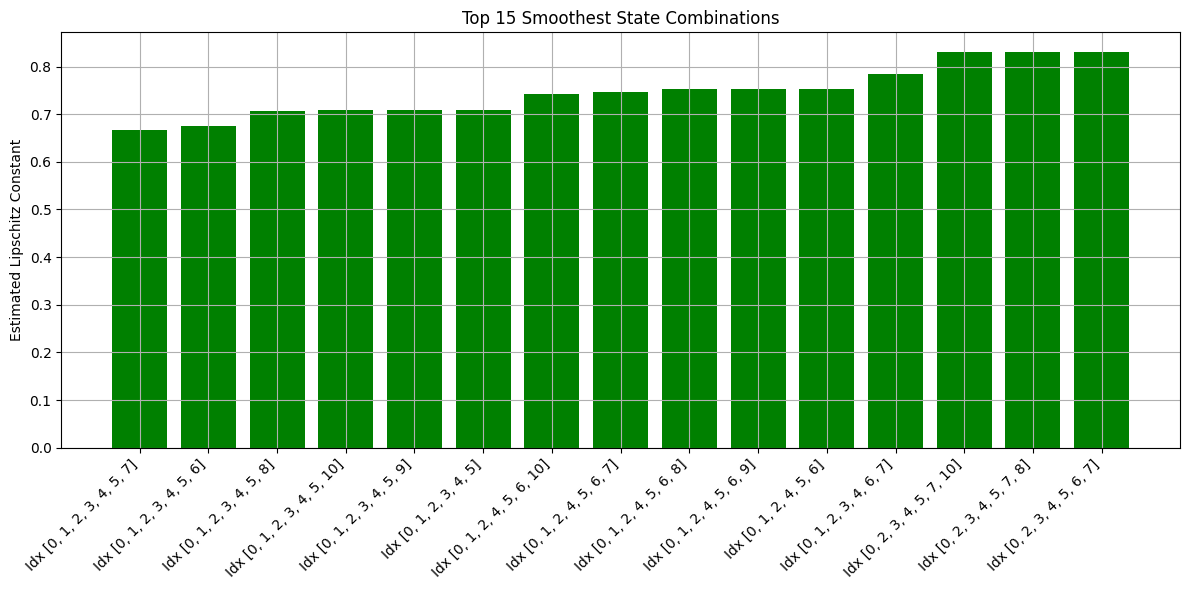

                     State Combo  Dim  Estimated Lipschitz
1486   Idx [0, 1, 2, 3, 4, 5, 7]    7             0.667103
1485   Idx [0, 1, 2, 3, 4, 5, 6]    7             0.675748
1487   Idx [0, 1, 2, 3, 4, 5, 8]    7             0.706679
1489  Idx [0, 1, 2, 3, 4, 5, 10]    7             0.708344
1488   Idx [0, 1, 2, 3, 4, 5, 9]    7             0.708455
1023      Idx [0, 1, 2, 3, 4, 5]    6             0.708563
1523  Idx [0, 1, 2, 4, 5, 6, 10]    7             0.742177
1520   Idx [0, 1, 2, 4, 5, 6, 7]    7             0.746408
1521   Idx [0, 1, 2, 4, 5, 6, 8]    7             0.752001
1522   Idx [0, 1, 2, 4, 5, 6, 9]    7             0.753721
1044      Idx [0, 1, 2, 4, 5, 6]    6             0.753721
1490   Idx [0, 1, 2, 3, 4, 6, 7]    7             0.784520
1617  Idx [0, 2, 3, 4, 5, 7, 10]    7             0.829558
1615   Idx [0, 2, 3, 4, 5, 7, 8]    7             0.830116
1611   Idx [0, 2, 3, 4, 5, 6, 7]    7             0.830226
1616   Idx [0, 2, 3, 4, 5, 7, 9]    7             0.8350

In [ ]:
import numpy as np
from itertools import combinations
import pandas as pd
import matplotlib.pyplot as plt

# 超参数
alpha = 0.5
beta = 0.3

# 定义 reward 函数（只依赖完整状态向量）
def reward_fn(s):
    p_a = s[0:2]
    p_i = s[4:6]
    Delta_i = s[8]
    R_sec = s[10]
    E = np.linalg.norm(p_a - p_i)
    return - (alpha * E + beta * Delta_i) + R_sec

# 随机生成完整状态向量
def generate_state():
    p_a = np.random.uniform(0, 100, 2)
    p_b = np.random.uniform(0, 100, 2)
    p_i = np.random.uniform(0, 100, 2)
    p_e = np.random.uniform(0, 100, 2)
    Delta_i = np.random.uniform(0, 5)
    s_c = np.random.choice([0, 1])
    R_sec = np.random.uniform(0, 10)
    return np.concatenate([p_a, p_b, p_i, p_e, [Delta_i, s_c, R_sec]])

# 生成样本
N = 100
states = np.array([generate_state() for _ in range(N)])

# 自动生成状态子集组合（最多组合长度）
full_dim = states.shape[1]
max_combo_dim = 7  # 可改为 6 或更多
all_combos = []
for k in range(1, max_combo_dim + 1):
    all_combos.extend(combinations(range(full_dim), k))

# 计算每个组合的 Lipschitz 常数
results = []
for idxs in all_combos:
    name = f"Idx {list(idxs)}"
    max_lip = 0
    for i, j in combinations(range(N), 2):
        s1, s2 = states[i][list(idxs)], states[j][list(idxs)]
        r1, r2 = reward_fn(states[i]), reward_fn(states[j])
        norm = np.linalg.norm(s1 - s2)
        if norm > 1e-8:
            lip = abs(r1 - r2) / norm
            max_lip = max(max_lip, lip)
    results.append((name, len(idxs), max_lip))

# 整理输出
df = pd.DataFrame(results, columns=["State Combo", "Dim", "Estimated Lipschitz"])
df_sorted = df.sort_values(by="Estimated Lipschitz")

# 可视化前 N 个组合（按平滑性从好到坏排序）
top_k = 15
plt.figure(figsize=(12,6))
plt.bar(df_sorted["State Combo"].iloc[:top_k], df_sorted["Estimated Lipschitz"].iloc[:top_k], color='green')
plt.xticks(rotation=45, ha='right')
plt.ylabel("Estimated Lipschitz Constant")
plt.title(f"Top {top_k} Smoothest State Combinations")
plt.grid(True)
plt.tight_layout()
plt.show()

# 显示表格前几行（可导出）
print(df_sorted.head(20))

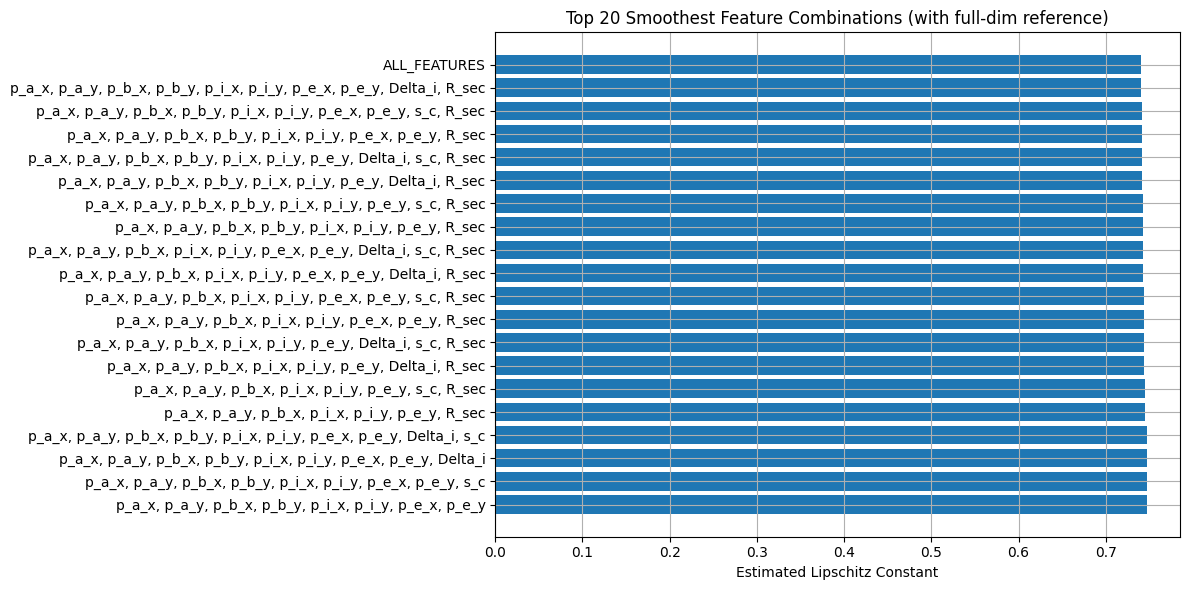

                                      Semantic Features  Dim  \
2046                                       ALL_FEATURES   11   
2036  p_a_x, p_a_y, p_b_x, p_b_y, p_i_x, p_i_y, p_e_...   10   
2037  p_a_x, p_a_y, p_b_x, p_b_y, p_i_x, p_i_y, p_e_...   10   
1982  p_a_x, p_a_y, p_b_x, p_b_y, p_i_x, p_i_y, p_e_...    9   
2039  p_a_x, p_a_y, p_b_x, p_b_y, p_i_x, p_i_y, p_e_...   10   
1987  p_a_x, p_a_y, p_b_x, p_b_y, p_i_x, p_i_y, p_e_...    9   
1988  p_a_x, p_a_y, p_b_x, p_b_y, p_i_x, p_i_y, p_e_...    9   
1821  p_a_x, p_a_y, p_b_x, p_b_y, p_i_x, p_i_y, p_e_...    8   
2042  p_a_x, p_a_y, p_b_x, p_i_x, p_i_y, p_e_x, p_e_...   10   
2002  p_a_x, p_a_y, p_b_x, p_i_x, p_i_y, p_e_x, p_e_...    9   
2003  p_a_x, p_a_y, p_b_x, p_i_x, p_i_y, p_e_x, p_e_...    9   
1852  p_a_x, p_a_y, p_b_x, p_i_x, p_i_y, p_e_x, p_e_...    8   
2005  p_a_x, p_a_y, p_b_x, p_i_x, p_i_y, p_e_y, Delt...    9   
1857  p_a_x, p_a_y, p_b_x, p_i_x, p_i_y, p_e_y, Delt...    8   
1858  p_a_x, p_a_y, p_b_x, p_i_x, p_i_y,

In [ ]:
import numpy as np
from itertools import combinations
import pandas as pd
import matplotlib.pyplot as plt

# 设置超参数
alpha = 0.5
beta = 0.3

# 原始状态语义标签与索引映射
feature_mapping = {
    "p_a_x": 0,
    "p_a_y": 1,
    "p_b_x": 2,
    "p_b_y": 3,
    "p_i_x": 4,
    "p_i_y": 5,
    "p_e_x": 6,
    "p_e_y": 7,
    "Delta_i": 8,
    "s_c": 9,
    "R_sec": 10
}
feature_names = list(feature_mapping.keys())

# 定义 reward 函数，基于完整状态向量
def reward_fn(s):
    p_a = s[0:2]
    p_i = s[4:6]
    Delta_i = s[8]
    R_sec = s[10]
    E = np.linalg.norm(p_a - p_i)
    return - (alpha * E + beta * Delta_i) + R_sec

# 生成状态样本
def generate_state():
    p_a = np.random.uniform(0, 100, 2)
    p_b = np.random.uniform(0, 100, 2)
    p_i = np.random.uniform(0, 100, 2)
    p_e = np.random.uniform(0, 100, 2)
    Delta_i = np.random.uniform(0, 5)
    s_c = np.random.choice([0, 1])
    R_sec = np.random.uniform(0, 10)
    return np.concatenate([p_a, p_b, p_i, p_e, [Delta_i, s_c, R_sec]])

# 构造状态样本
N = 100
states = np.array([generate_state() for _ in range(N)])

# 设置最大组合维度
max_combo_dim = 10
full_dim = len(feature_names)

# 枚举所有语义维度组合
results = []
for k in range(1, max_combo_dim + 1):
    for idx_combo in combinations(range(full_dim), k):
        feature_combo = [feature_names[i] for i in idx_combo]
        indices = list(idx_combo)
        max_lip = 0
        for i in range(N):
            for j in range(i+1, N):
                s1, s2 = states[i][indices], states[j][indices]
                r1, r2 = reward_fn(states[i]), reward_fn(states[j])
                norm = np.linalg.norm(s1 - s2)
                if norm > 1e-8:
                    lip = abs(r1 - r2) / norm
                    max_lip = max(max_lip, lip)
        results.append((", ".join(feature_combo), len(indices), max_lip))

# 添加完整维度的 Lipschitz 值
all_indices = list(range(full_dim))
max_lip_full = 0
for i in range(N):
    for j in range(i+1, N):
        s1, s2 = states[i][all_indices], states[j][all_indices]
        r1, r2 = reward_fn(states[i]), reward_fn(states[j])
        norm = np.linalg.norm(s1 - s2)
        if norm > 1e-8:
            lip = abs(r1 - r2) / norm
            max_lip_full = max(max_lip_full, lip)
results.append(("ALL_FEATURES", full_dim, max_lip_full))

# 转换为 DataFrame
df = pd.DataFrame(results, columns=["Semantic Features", "Dim", "Estimated Lipschitz"])
df_sorted = df.sort_values(by="Estimated Lipschitz")

# 可视化前若干组合
top_k = 20
plt.figure(figsize=(12,6))
plt.barh(df_sorted["Semantic Features"].iloc[:top_k][::-1],
         df_sorted["Estimated Lipschitz"].iloc[:top_k][::-1])
plt.xlabel("Estimated Lipschitz Constant")
plt.title(f"Top {top_k} Smoothest Feature Combinations (with full-dim reference)")
plt.grid(True)
plt.tight_layout()
plt.show()

# 输出表格前几行结果
print(df_sorted.head(20))

# 单独输出 full 维度对比值
print(f"\nLipschitz for ALL_FEATURES (full 11-dim state): {max_lip_full:.6f}")

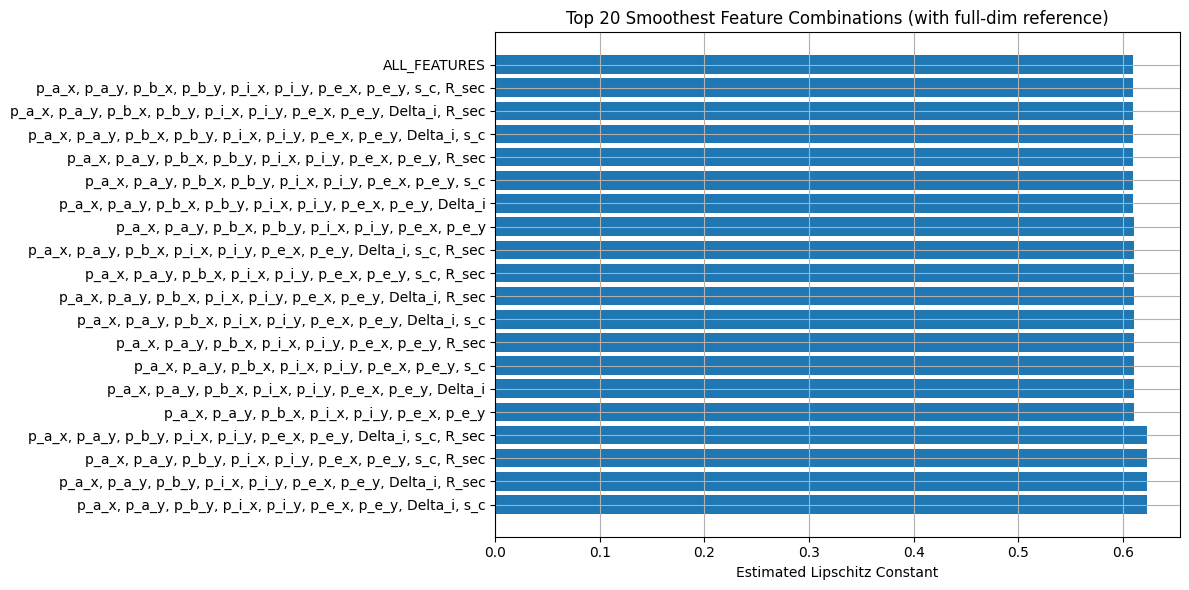

                                      Semantic Features  Dim  \
2046                                       ALL_FEATURES   11   
2037  p_a_x, p_a_y, p_b_x, p_b_y, p_i_x, p_i_y, p_e_...   10   
2036  p_a_x, p_a_y, p_b_x, p_b_y, p_i_x, p_i_y, p_e_...   10   
2035  p_a_x, p_a_y, p_b_x, p_b_y, p_i_x, p_i_y, p_e_...   10   
1982  p_a_x, p_a_y, p_b_x, p_b_y, p_i_x, p_i_y, p_e_...    9   
1981  p_a_x, p_a_y, p_b_x, p_b_y, p_i_x, p_i_y, p_e_...    9   
1980  p_a_x, p_a_y, p_b_x, p_b_y, p_i_x, p_i_y, p_e_...    9   
1815  p_a_x, p_a_y, p_b_x, p_b_y, p_i_x, p_i_y, p_e_...    8   
2042  p_a_x, p_a_y, p_b_x, p_i_x, p_i_y, p_e_x, p_e_...   10   
2003  p_a_x, p_a_y, p_b_x, p_i_x, p_i_y, p_e_x, p_e_...    9   
2002  p_a_x, p_a_y, p_b_x, p_i_x, p_i_y, p_e_x, p_e_...    9   
2001  p_a_x, p_a_y, p_b_x, p_i_x, p_i_y, p_e_x, p_e_...    9   
1852  p_a_x, p_a_y, p_b_x, p_i_x, p_i_y, p_e_x, p_e_...    8   
1851  p_a_x, p_a_y, p_b_x, p_i_x, p_i_y, p_e_x, p_e_...    8   
1850  p_a_x, p_a_y, p_b_x, p_i_x, p_i_y,

In [ ]:
import numpy as np
from itertools import combinations
import pandas as pd
import matplotlib.pyplot as plt

# 设置 reward 权重系数
alpha = 0.5  # 权重：能耗
beta = 0.3   # 权重：AoI

# 特征名称及索引映射，依据论文中的系统建模部分
feature_mapping = {
    "p_a_x": 0,     # UAV_a 横坐标
    "p_a_y": 1,     # UAV_a 纵坐标
    "p_b_x": 2,     # UAV_b 横坐标
    "p_b_y": 3,     # UAV_b 纵坐标
    "p_i_x": 4,     # Edge Device 横坐标
    "p_i_y": 5,     # Edge Device 纵坐标
    "p_e_x": 6,     # Eavesdropper 横坐标
    "p_e_y": 7,     # Eavesdropper 纵坐标
    "Delta_i": 8,   # 当前设备 AoI
    "s_c": 9,       # 信道是否占用（0空闲，1占用）
    "R_sec": 10     # 当前保密速率 R_{s,i,c}
}
feature_names = list(feature_mapping.keys())

# 定义 reward 函数（论文目标函数）： - (α * E + β * AoI) + R_sec
def reward_fn(s):
    p_a = s[0:2]  # UAV_a 位置
    p_i = s[4:6]  # edge device 位置
    Delta_i = s[8]
    R_sec = s[10]
    E = np.linalg.norm(p_a - p_i)  # 传输距离
    return - (alpha * E + beta * Delta_i) + R_sec

# 构造随机状态样本（简化模拟）
def generate_state():
    p_a = np.random.uniform(0, 100, 2)
    p_b = np.random.uniform(0, 100, 2)
    p_i = np.random.uniform(0, 100, 2)
    p_e = np.random.uniform(0, 100, 2)
    Delta_i = np.random.uniform(0, 10)
    s_c = np.random.choice([0, 1])
    R_sec = np.random.uniform(0, 5)
    return np.concatenate([p_a, p_b, p_i, p_e, [Delta_i, s_c, R_sec]])

# 生成状态集合
N = 100
states = np.array([generate_state() for _ in range(N)])

# 设定最大语义组合维度
max_combo_dim = 10
full_dim = len(feature_names)

results = []
for k in range(1, max_combo_dim + 1):
    for idx_combo in combinations(range(full_dim), k):
        feature_combo = [feature_names[i] for i in idx_combo]
        indices = list(idx_combo)
        max_lip = 0
        for i in range(N):
            for j in range(i+1, N):
                s1 = states[i][indices]
                s2 = states[j][indices]
                r1 = reward_fn(states[i])
                r2 = reward_fn(states[j])
                norm = np.linalg.norm(s1 - s2)
                if norm > 1e-8:
                    lip = abs(r1 - r2) / norm
                    max_lip = max(max_lip, lip)
        results.append((", ".join(feature_combo), len(indices), max_lip))

# 计算全特征的 Lipschitz 值（对比参考）
all_indices = list(range(full_dim))
max_lip_full = 0
for i in range(N):
    for j in range(i+1, N):
        s1 = states[i][all_indices]
        s2 = states[j][all_indices]
        r1 = reward_fn(states[i])
        r2 = reward_fn(states[j])
        norm = np.linalg.norm(s1 - s2)
        if norm > 1e-8:
            lip = abs(r1 - r2) / norm
            max_lip_full = max(max_lip_full, lip)
results.append(("ALL_FEATURES", full_dim, max_lip_full))

# 转换为 DataFrame
df = pd.DataFrame(results, columns=["Semantic Features", "Dim", "Estimated Lipschitz"])
df_sorted = df.sort_values(by="Estimated Lipschitz")

# 可视化前 K 个组合
top_k = 20
plt.figure(figsize=(12, 6))
plt.barh(df_sorted["Semantic Features"].iloc[:top_k][::-1],
         df_sorted["Estimated Lipschitz"].iloc[:top_k][::-1])
plt.xlabel("Estimated Lipschitz Constant")
plt.title(f"Top {top_k} Smoothest Feature Combinations (with full-dim reference)")
plt.grid(True)
plt.tight_layout()
plt.show()

# 输出表格前几行结果
print(df_sorted.head(20))

# 输出全维度参考值
print(f"\nLipschitz for ALL_FEATURES (full 11-dim state): {max_lip_full:.6f}")

In [ ]:
import numpy as np
from itertools import combinations
import pandas as pd
import matplotlib.pyplot as plt

# 设置超参数
alpha = 0.5
beta = 0.3

# 更新状态语义标签映射（新增5个设备的x/y）
feature_mapping = {
    "p_a_x": 0,
    "p_a_y": 1,
    "p_b_x": 2,
    "p_b_y": 3,
    "p_i_x": 4,
    "p_i_y": 5,
    "p_e_x": 6,
    "p_e_y": 7,
    "Delta_i": 8,
    "s_c": 9,
    "R_sec": 10,
    "dev1_x": 11,
    "dev1_y": 12,
    "dev2_x": 13,
    "dev2_y": 14,
    "dev3_x": 15,
    "dev3_y": 16,
    "dev4_x": 17,
    "dev4_y": 18,
    "dev5_x": 19,
    "dev5_y": 20
}
feature_names = list(feature_mapping.keys())

# 定义 reward 函数（仍使用核心维度）
def reward_fn(s):
    p_a = s[0:2]
    p_i = s[4:6]
    Delta_i = s[8]
    R_sec = s[10]
    E = np.linalg.norm(p_a - p_i)
    return - (alpha * E + beta * Delta_i) + R_sec

# 生成状态样本
def generate_state():
    p_a = np.random.uniform(0, 100, 2)
    p_b = np.random.uniform(0, 100, 2)
    p_i = np.random.uniform(0, 100, 2)
    p_e = np.random.uniform(0, 100, 2)
    Delta_i = np.random.uniform(0, 5)
    s_c = np.random.choice([0, 1])
    R_sec = np.random.uniform(0, 10)
    dev_coords = np.random.uniform(0, 100, 10)  # 5设备的 x/y
    return np.concatenate([p_a, p_b, p_i, p_e, [Delta_i, s_c, R_sec], dev_coords])

# 构造状态样本
N = 100
states = np.array([generate_state() for _ in range(N)])

# 设置最大组合维度（你可以改成任意值，最大为 21）
max_combo_dim = 13
full_dim = len(feature_names)

# 枚举所有语义维度组合
results = []
for k in range(1, max_combo_dim + 1):
    for idx_combo in combinations(range(full_dim), k):
        feature_combo = [feature_names[i] for i in idx_combo]
        indices = list(idx_combo)
        max_lip = 0
        for i in range(N):
            for j in range(i+1, N):
                s1, s2 = states[i][indices], states[j][indices]
                r1, r2 = reward_fn(states[i]), reward_fn(states[j])
                norm = np.linalg.norm(s1 - s2)
                if norm > 1e-8:
                    lip = abs(r1 - r2) / norm
                    max_lip = max(max_lip, lip)
        results.append((", ".join(feature_combo), len(indices), max_lip))

# 添加完整维度的 Lipschitz 值
all_indices = list(range(full_dim))
max_lip_full = 0
for i in range(N):
    for j in range(i+1, N):
        s1, s2 = states[i][all_indices], states[j][all_indices]
        r1, r2 = reward_fn(states[i]), reward_fn(states[j])
        norm = np.linalg.norm(s1 - s2)
        if norm > 1e-8:
            lip = abs(r1 - r2) / norm
            max_lip_full = max(max_lip_full, lip)
results.append(("ALL_FEATURES", full_dim, max_lip_full))

# 转换为 DataFrame
df = pd.DataFrame(results, columns=["Semantic Features", "Dim", "Estimated Lipschitz"])
df_sorted = df.sort_values(by="Estimated Lipschitz")

# 可视化前若干组合
top_k = 20
plt.figure(figsize=(12,6))
plt.barh(df_sorted["Semantic Features"].iloc[:top_k][::-1],
         df_sorted["Estimated Lipschitz"].iloc[:top_k][::-1])
plt.xlabel("Estimated Lipschitz Constant")
plt.title(f"Top {top_k} Smoothest Feature Combinations (with full-dim reference)")
plt.grid(True)
plt.tight_layout()
plt.show()

# 输出表格前几行结果
print(df_sorted.head(20))

# 单独输出 full 维度对比值
print(f"\nLipschitz for ALL_FEATURES (full {full_dim}-dim state): {max_lip_full:.6f}")

KeyboardInterrupt: 

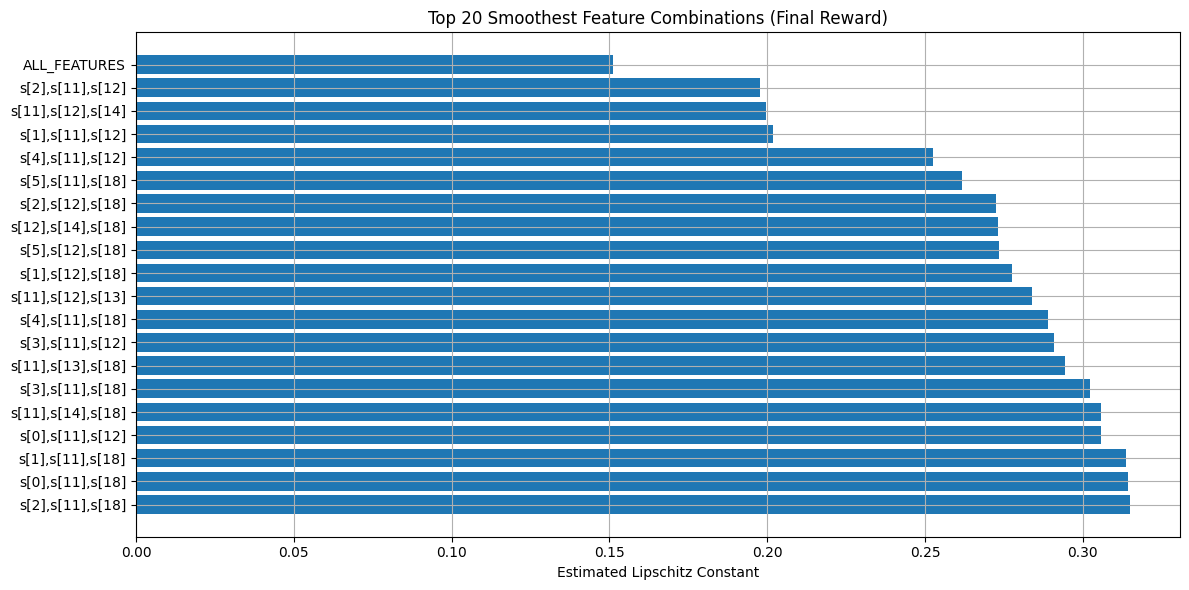

      Semantic Features  Dim  Estimated Lipschitz
1159       ALL_FEATURES   19             0.151036
571    s[2],s[11],s[12]    3             0.197580
1104  s[11],s[12],s[14]    3             0.199760
451    s[1],s[11],s[12]    3             0.201980
767    s[4],s[11],s[12]    3             0.252578
851    s[5],s[11],s[18]    3             0.261742
583    s[2],s[12],s[18]    3             0.272558
1132  s[12],s[14],s[18]    3             0.273023
857    s[5],s[12],s[18]    3             0.273545
463    s[1],s[12],s[18]    3             0.277739
1103  s[11],s[12],s[13]    3             0.283778
773    s[4],s[11],s[18]    3             0.288878
676    s[3],s[11],s[12]    3             0.290804
1113  s[11],s[13],s[18]    3             0.294331
682    s[3],s[11],s[18]    3             0.302193
1117  s[11],s[14],s[18]    3             0.305822
315    s[0],s[11],s[12]    3             0.305840
457    s[1],s[11],s[18]    3             0.313614
321    s[0],s[11],s[18]    3             0.314224


In [ ]:
import numpy as np
from itertools import combinations
import pandas as pd
import matplotlib.pyplot as plt

# 配置参数
LAMBDA_INTRINSIC = 0.8
alpha = 0.1  # 主奖励中能耗权重
beta = 0.1   # 主奖励中 AoI 权重
num_features = 19  # revise_state 之后的状态长度

# -------------------------
# Ground IoTD positions
# -------------------------
IOTD_POS = np.array([
    [50, 50, 0],
    [75, 150, 0],
    [100, 100, 0],
    [100, 250, 0],
    [150, 150, 0]
])

# -------------------------
# revise_state 函数
# -------------------------
def revise_state(s: np.ndarray) -> np.ndarray:
    uav_a = s[0:3]
    uav_b = s[3:6]
    aoi = s[6:11]
    e_a, e_b = s[11], s[12]

    def dist(a, b):
        return np.linalg.norm(a - b, ord=2)

    inter_uav_dist = dist(uav_a, uav_b)
    dists_a = np.linalg.norm(IOTD_POS - uav_a, axis=1)
    dists_b = np.linalg.norm(IOTD_POS - uav_b, axis=1)
    d_a_min = dists_a.min()
    d_b_min = dists_b.min()
    max_aoi = aoi.max()
    mean_aoi = aoi.mean()
    energy_balance = e_a - e_b

    engineered = np.array([
        inter_uav_dist,
        d_a_min,
        d_b_min,
        max_aoi,
        mean_aoi,
        energy_balance,
    ], dtype=s.dtype)

    return np.concatenate([s, engineered])

# -------------------------
# 构造状态样本
# -------------------------
def generate_state():
    uav_a = np.random.uniform(0, 300, 3)
    uav_b = np.random.uniform(0, 300, 3)
    aoi = np.random.uniform(0, 10, 5)
    e_a = np.random.uniform(0, 500)
    e_b = np.random.uniform(0, 500)
    s_raw = np.concatenate([uav_a, uav_b, aoi, [e_a, e_b]])
    return revise_state(s_raw)

# -------------------------
# 主环境奖励函数（模拟）
# -------------------------
def env_reward(s_aug):
    mean_aoi = s_aug[17]
    energy_sum = s_aug[11] + s_aug[12]
    return - alpha * energy_sum - beta * mean_aoi

# -------------------------
# intrinsic_reward 函数
# -------------------------
def intrinsic_reward(s_aug):
    mean_aoi = s_aug[17]
    e_total = s_aug[11] + s_aug[12]
    inter_uav_dist = s_aug[13]
    d_a_min = s_aug[14]
    d_b_min = s_aug[15]
    w_aoi = 1.0
    w_energy = 1e-2
    w_d2iot = 1e-3
    w_duav = 5e-3
    reward = -(
        w_aoi * mean_aoi
        + w_energy * e_total
        + w_d2iot * (d_a_min + d_b_min)
        + w_duav * inter_uav_dist
    )
    return float(reward)

# -------------------------
# 完整 reward 函数
# -------------------------
def reward_fn(s_aug):
    return env_reward(s_aug) + LAMBDA_INTRINSIC * intrinsic_reward(s_aug)

# -------------------------
# 生成状态集并计算 Lipschitz
# -------------------------
N = 100
aug_states = [generate_state() for _ in range(N)]
rewards = [reward_fn(s) for s in aug_states]

results = []
max_combo_dim = 3

for k in range(1, max_combo_dim + 1):
    for idx_combo in combinations(range(num_features), k):
        max_lip = 0
        for i in range(N):
            for j in range(i + 1, N):
                s1 = aug_states[i][list(idx_combo)]
                s2 = aug_states[j][list(idx_combo)]
                r1, r2 = rewards[i], rewards[j]
                dist = np.linalg.norm(s1 - s2)
                if dist > 1e-8:
                    lip = abs(r1 - r2) / dist
                    max_lip = max(max_lip, lip)
        feat_combo = [f"s[{i}]" for i in idx_combo]
        results.append((",".join(feat_combo), len(idx_combo), max_lip))

# 全特征 Lipschitz
full_idx = list(range(num_features))
max_lip_full = 0
for i in range(N):
    for j in range(i + 1, N):
        s1 = aug_states[i][full_idx]
        s2 = aug_states[j][full_idx]
        r1, r2 = rewards[i], rewards[j]
        dist = np.linalg.norm(s1 - s2)
        if dist > 1e-8:
            lip = abs(r1 - r2) / dist
            max_lip_full = max(max_lip_full, lip)

results.append(("ALL_FEATURES", num_features, max_lip_full))

# 结果展示
df = pd.DataFrame(results, columns=["Semantic Features", "Dim", "Estimated Lipschitz"])
df_sorted = df.sort_values(by="Estimated Lipschitz")

# 可视化
top_k = 20
plt.figure(figsize=(12, 6))
plt.barh(df_sorted["Semantic Features"].iloc[:top_k][::-1],
         df_sorted["Estimated Lipschitz"].iloc[:top_k][::-1])
plt.xlabel("Estimated Lipschitz Constant")
plt.title(f"Top {top_k} Smoothest Feature Combinations (Final Reward)")
plt.grid(True)
plt.tight_layout()
plt.show()

# 输出前几行结果和整体 Lipschitz
print(df_sorted.head(20))
print(f"\nLipschitz for ALL_FEATURES (full 19-dim augmented state): {max_lip_full:.6f}")

**# 计算增强状态到增加强奖励**

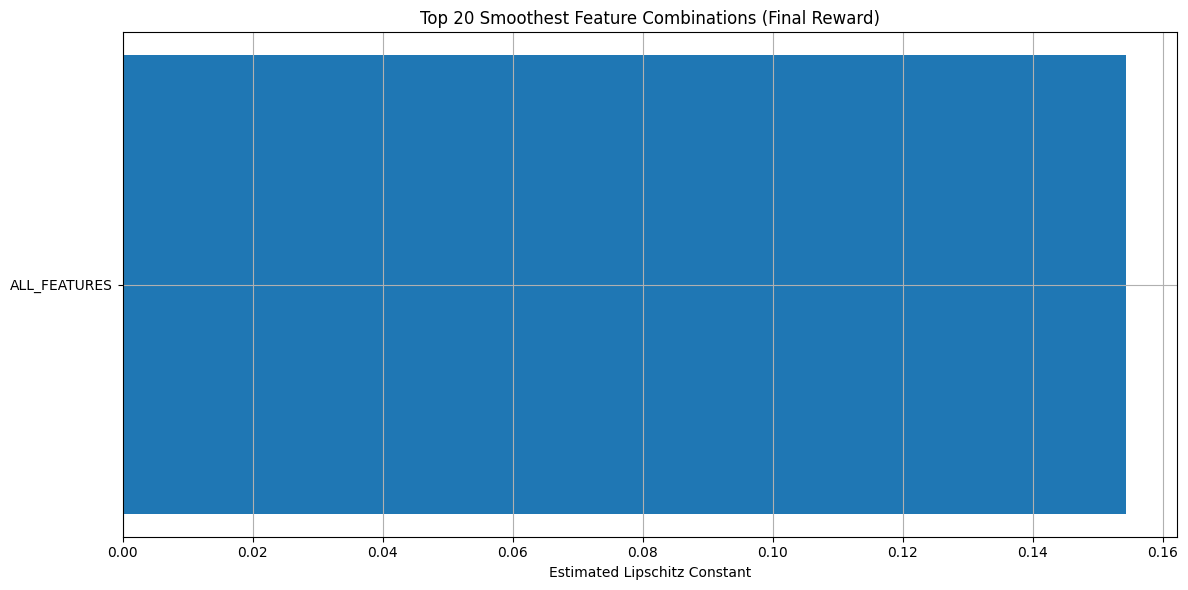

  Semantic Features  Dim  Estimated Lipschitz
0      ALL_FEATURES   19             0.154395

Lipschitz for ALL_FEATURES (full 19-dim augmented state): 0.154395


In [ ]:
import numpy as np
from itertools import combinations
import pandas as pd
import matplotlib.pyplot as plt

# 配置参数
LAMBDA_INTRINSIC = 0.8
alpha = 0.1  # 主奖励中能耗权重
beta = 0.1   # 主奖励中 AoI 权重
num_features = 19  # revise_state 之后的状态长度

# -------------------------
# Ground IoTD positions
# -------------------------
IOTD_POS = np.array([
    [50, 50, 0],
    [75, 150, 0],
    [100, 100, 0],
    [100, 250, 0],
    [150, 150, 0]
])

# -------------------------
# revise_state 函数
# -------------------------
def revise_state(s: np.ndarray) -> np.ndarray:
    uav_a = s[0:3]
    uav_b = s[3:6]
    aoi = s[6:11]
    e_a, e_b = s[11], s[12]

    def dist(a, b):
        return np.linalg.norm(a - b, ord=2)

    inter_uav_dist = dist(uav_a, uav_b)
    dists_a = np.linalg.norm(IOTD_POS - uav_a, axis=1)
    dists_b = np.linalg.norm(IOTD_POS - uav_b, axis=1)
    d_a_min = dists_a.min()
    d_b_min = dists_b.min()
    max_aoi = aoi.max()
    mean_aoi = aoi.mean()
    energy_balance = e_a - e_b

    engineered = np.array([
        inter_uav_dist,
        d_a_min,
        d_b_min,
        max_aoi,
        mean_aoi,
        energy_balance,
    ], dtype=s.dtype)

    return np.concatenate([s, engineered])

# -------------------------
# 构造状态样本
# -------------------------
def generate_state():
    uav_a = np.random.uniform(0, 300, 3)
    uav_b = np.random.uniform(0, 300, 3)
    aoi = np.random.uniform(0, 10, 5)
    e_a = np.random.uniform(0, 500)
    e_b = np.random.uniform(0, 500)
    s_raw = np.concatenate([uav_a, uav_b, aoi, [e_a, e_b]])
    return revise_state(s_raw)

# -------------------------
# 主环境奖励函数（模拟）
# -------------------------
def env_reward(s_aug):
    mean_aoi = s_aug[17]
    energy_sum = s_aug[11] + s_aug[12]
    return - alpha * energy_sum - beta * mean_aoi

# -------------------------
# intrinsic_reward 函数
# -------------------------
def intrinsic_reward(s_aug):
    mean_aoi = s_aug[17]
    e_total = s_aug[11] + s_aug[12]
    inter_uav_dist = s_aug[13]
    d_a_min = s_aug[14]
    d_b_min = s_aug[15]
    w_aoi = 1.0
    w_energy = 1e-2
    w_d2iot = 1e-3
    w_duav = 5e-3
    reward = -(
        w_aoi * mean_aoi
        + w_energy * e_total
        + w_d2iot * (d_a_min + d_b_min)
        + w_duav * inter_uav_dist
    )
    return float(reward)

# -------------------------
# 完整 reward 函数
# -------------------------
def reward_fn(s_aug):
    return env_reward(s_aug) + LAMBDA_INTRINSIC * intrinsic_reward(s_aug)

# -------------------------
# 生成状态集并计算 Lipschitz
# -------------------------
N = 500
aug_states = [generate_state() for _ in range(N)]
rewards = [reward_fn(s) for s in aug_states]

results = []
max_combo_dim = 0

for k in range(1, max_combo_dim + 1):
    for idx_combo in combinations(range(num_features), k):
        max_lip = 0
        for i in range(N):
            for j in range(i + 1, N):
                s1 = aug_states[i][list(idx_combo)]
                s2 = aug_states[j][list(idx_combo)]
                r1, r2 = rewards[i], rewards[j]
                dist = np.linalg.norm(s1 - s2)
                if dist > 1e-8:
                    lip = abs(r1 - r2) / dist
                    max_lip = max(max_lip, lip)
        feat_combo = [f"s[{i}]" for i in idx_combo]
        results.append((",".join(feat_combo), len(idx_combo), max_lip))

# 全特征 Lipschitz
full_idx = list(range(num_features))
max_lip_full = 0
for i in range(N):
    for j in range(i + 1, N):
        s1 = aug_states[i][full_idx]
        s2 = aug_states[j][full_idx]
        r1, r2 = rewards[i], rewards[j]
        dist = np.linalg.norm(s1 - s2)
        if dist > 1e-8:
            lip = abs(r1 - r2) / dist
            max_lip_full = max(max_lip_full, lip)

results.append(("ALL_FEATURES", num_features, max_lip_full))

# 结果展示
df = pd.DataFrame(results, columns=["Semantic Features", "Dim", "Estimated Lipschitz"])
df_sorted = df.sort_values(by="Estimated Lipschitz")

# 可视化
top_k = 20
plt.figure(figsize=(12, 6))
plt.barh(df_sorted["Semantic Features"].iloc[:top_k][::-1],
         df_sorted["Estimated Lipschitz"].iloc[:top_k][::-1])
plt.xlabel("Estimated Lipschitz Constant")
plt.title(f"Top {top_k} Smoothest Feature Combinations (Final Reward)")
plt.grid(True)
plt.tight_layout()
plt.show()

# 输出前几行结果和整体 Lipschitz
print(df_sorted.head(20))
print(f"\nLipschitz for ALL_FEATURES (full 19-dim augmented state): {max_lip_full:.6f}")

In [ ]:
import numpy as np
from itertools import combinations
import pandas as pd
import matplotlib.pyplot as plt

# 配置参数
LAMBDA_INTRINSIC = 0.8
alpha = 0.1  # 主奖励中能耗权重
beta = 0.1   # 主奖励中 AoI 权重
num_features = 19  # revise_state 之后的状态长度
raw_dim = 13       # 原始状态长度

# -------------------------
# Ground IoTD positions
# -------------------------
IOTD_POS = np.array([
    [50, 50, 0],
    [75, 150, 0],
    [100, 100, 0],
    [100, 250, 0],
    [150, 150, 0]
])

# -------------------------
# revise_state 函数
# -------------------------
def revise_state(s: np.ndarray) -> np.ndarray:
    uav_a = s[0:3]
    uav_b = s[3:6]
    aoi = s[6:11]
    e_a, e_b = s[11], s[12]

    def dist(a, b):
        return np.linalg.norm(a - b, ord=2)

    inter_uav_dist = dist(uav_a, uav_b)
    dists_a = np.linalg.norm(IOTD_POS - uav_a, axis=1)
    dists_b = np.linalg.norm(IOTD_POS - uav_b, axis=1)
    d_a_min = dists_a.min()
    d_b_min = dists_b.min()
    max_aoi = aoi.max()
    mean_aoi = aoi.mean()
    energy_balance = e_a - e_b

    engineered = np.array([
        inter_uav_dist,
        d_a_min,
        d_b_min,
        max_aoi,
        mean_aoi,
        energy_balance,
    ], dtype=s.dtype)

    return np.concatenate([s, engineered])

# -------------------------
# 构造状态样本（返回原始与增强状态）
# -------------------------
def generate_state():
    uav_a = np.random.uniform(0, 300, 3)
    uav_b = np.random.uniform(0, 300, 3)
    aoi = np.random.uniform(0, 10, 5)
    e_a = np.random.uniform(0, 500)
    e_b = np.random.uniform(0, 500)
    s_raw = np.concatenate([uav_a, uav_b, aoi, [e_a, e_b]])
    return s_raw, revise_state(s_raw)

# -------------------------
# 主环境奖励函数（用于原始与增强）
# -------------------------
def env_reward(s_aug):
    mean_aoi = s_aug[17]
    energy_sum = s_aug[11] + s_aug[12]
    return - alpha * energy_sum - beta * mean_aoi

# -------------------------
# intrinsic_reward 函数
# -------------------------
def intrinsic_reward(s_aug):
    mean_aoi = s_aug[17]
    e_total = s_aug[11] + s_aug[12]
    inter_uav_dist = s_aug[13]
    d_a_min = s_aug[14]
    d_b_min = s_aug[15]
    w_aoi = 1.0
    w_energy = 1e-2
    w_d2iot = 1e-3
    w_duav = 5e-3
    reward = -(
        w_aoi * mean_aoi
        + w_energy * e_total
        + w_d2iot * (d_a_min + d_b_min)
        + w_duav * inter_uav_dist
    )
    return float(reward)

# -------------------------
# 完整 reward 函数（增强状态）
# -------------------------
def reward_fn(s_aug):
    return env_reward(s_aug) + LAMBDA_INTRINSIC * intrinsic_reward(s_aug)

# -------------------------
# 生成状态集并计算两种 Lipschitz
# -------------------------
N = 1000
raw_states = []
aug_states = []
raw_rewards = []
aug_rewards = []

for _ in range(N):
    s_raw, s_aug = generate_state()
    raw_states.append(s_raw)
    aug_states.append(s_aug)
    raw_rewards.append(env_reward(s_aug))   # 对照组：用增强状态计算 env_reward
    aug_rewards.append(reward_fn(s_aug))    # 实验组：增强状态计算 final_reward

# 计算 Lipschitz（增强状态 → final_reward）
max_lip_aug = 0
for i in range(N):
    for j in range(i + 1, N):
        s1 = aug_states[i]
        s2 = aug_states[j]
        r1 = aug_rewards[i]
        r2 = aug_rewards[j]
        dist = np.linalg.norm(s1 - s2)
        if dist > 1e-8:
            lip = abs(r1 - r2) / dist
            max_lip_aug = max(max_lip_aug, lip)



# -------------------------
# 输出结果
# -------------------------


print(f"Lipschitz for AUG_STATE → FINAL_REWARD: {max_lip_aug:.6f}")

Lipschitz for AUG_STATE → FINAL_REWARD: 0.160021


!!!!!官方计算L常数代码!!!!!这段代码比较了main reward和V4-2代码版本种的main reward+内在奖励的L常数，而且实验除出了main reward的权重小会显著改进L常数，在实验中也对应验证了

In [ ]:
#对照 原始状态-原始奖励 增强状态-增强奖励

In [ ]:
import numpy as np
from itertools import combinations
import pandas as pd
import matplotlib.pyplot as plt

# 配置参数
LAMBDA_INTRINSIC = 1.0
alpha = 0.1  # 主奖励中能耗权重
beta = 0.1   # 主奖励中 AoI 权重
num_features = 19  # revise_state 之后的状态长度
raw_dim = 13       # 原始状态长度

# -------------------------
# Ground IoTD positions
# -------------------------
IOTD_POS = np.array([
    [50, 50, 0],
    [75, 150, 0],
    [100, 100, 0],
    [100, 250, 0],
    [150, 150, 0]
])

# -------------------------
# revise_state 函数
# -------------------------
def revise_state(s: np.ndarray) -> np.ndarray:
    uav_a = s[0:3]
    uav_b = s[3:6]
    aoi = s[6:11]
    e_a, e_b = s[11], s[12]

    def dist(a, b):
        return np.linalg.norm(a - b, ord=2)

    inter_uav_dist = dist(uav_a, uav_b)
    dists_a = np.linalg.norm(IOTD_POS - uav_a, axis=1)
    dists_b = np.linalg.norm(IOTD_POS - uav_b, axis=1)
    d_a_min = dists_a.min()
    d_b_min = dists_b.min()
    max_aoi = aoi.max()
    mean_aoi = aoi.mean()
    energy_balance = e_a - e_b

    engineered = np.array([
        inter_uav_dist,
        d_a_min,
        d_b_min,
        max_aoi,
        mean_aoi,
        energy_balance,
    ], dtype=s.dtype)

    return np.concatenate([s, engineered])

# -------------------------
# 构造状态样本（返回原始与增强状态）
# -------------------------
def generate_state():
    uav_a = np.random.uniform(0, 300, 3)
    uav_b = np.random.uniform(0, 300, 3)
    aoi = np.random.uniform(0, 10, 5)
    e_a = np.random.uniform(0, 500)
    e_b = np.random.uniform(0, 500)
    s_raw = np.concatenate([uav_a, uav_b, aoi, [e_a, e_b]])
    return s_raw, revise_state(s_raw)

# -------------------------
# 主环境奖励函数（用于原始与增强）
# -------------------------
def env_reward(s_aug):
    mean_aoi = s_aug[17]
    energy_sum = s_aug[11] + s_aug[12]
    return - alpha * energy_sum - beta * mean_aoi

# -------------------------
# intrinsic_reward 函数
# -------------------------
def intrinsic_reward(s_aug):
    mean_aoi = s_aug[17]
    e_total = s_aug[11] + s_aug[12]
    inter_uav_dist = s_aug[13]
    d_a_min = s_aug[14]
    d_b_min = s_aug[15]
    w_aoi = 1.0
    w_energy = 1e-3
    w_d2iot = 1e-3
    w_duav = 5e-3
    reward = -(
        w_aoi * mean_aoi
        + w_energy * e_total
        + w_d2iot * (d_a_min + d_b_min)
        + w_duav * inter_uav_dist
    )
    return float(reward)

# -------------------------
# 完整 reward 函数（增强状态）
# -------------------------
def reward_fn(s_aug):
    return 0.1 * env_reward(s_aug) + LAMBDA_INTRINSIC * intrinsic_reward(s_aug)

# -------------------------
# 生成状态集并计算两种 Lipschitz
# -------------------------
N = 5000
raw_states = []
aug_states = []
raw_rewards = []
aug_rewards = []

for _ in range(N):
    s_raw, s_aug = generate_state()
    raw_states.append(s_raw)
    aug_states.append(s_aug)
    raw_rewards.append(env_reward(s_aug))   # 对照组：用增强状态计算 env_reward
    aug_rewards.append(reward_fn(s_aug))    # 实验组：增强状态计算 final_reward

# 计算 Lipschitz（增强状态 → final_reward）
max_lip_aug = 0
for i in range(N):
    for j in range(i + 1, N):
        s1 = aug_states[i]
        s2 = aug_states[j]
        r1 = aug_rewards[i]
        r2 = aug_rewards[j]
        dist = np.linalg.norm(s1 - s2)
        if dist > 1e-8:
            lip = abs(r1 - r2) / dist
            max_lip_aug = max(max_lip_aug, lip)

# 计算 Lipschitz（原始状态 → env_reward）
max_lip_raw = 0
for i in range(N):
    for j in range(i + 1, N):
        s1 = raw_states[i]
        s2 = raw_states[j]
        r1 = raw_rewards[i]
        r2 = raw_rewards[j]
        dist = np.linalg.norm(s1 - s2)
        if dist > 1e-8:
            lip = abs(r1 - r2) / dist
            max_lip_raw = max(max_lip_raw, lip)

# -------------------------
# 输出结果
# -------------------------
print(f"Lipschitz for RAW_STATE → ENV_REWARD:   {max_lip_raw:.6f}")
print(f"Lipschitz for AUG_STATE → FINAL_REWARD: {max_lip_aug:.6f}")

Lipschitz for RAW_STATE → ENV_REWARD:   0.141805
Lipschitz for AUG_STATE → FINAL_REWARD: 0.078020


In [ ]:
import numpy as np
import pandas as pd
from tqdm import tqdm

# 配置参数
LAMBDA_INTRINSIC = 1.0
alpha = 0.1
beta = 0.1
raw_dim = 13
aug19_dim = 19
aug23_dim = 23

# IoTD 坐标
IOTD_POS = np.array([
    [50, 50, 0],
    [75, 150, 0],
    [100, 100, 0],
    [100, 250, 0],
    [150, 150, 0]
])

# revise_state_19
def revise_state_19(s: np.ndarray) -> np.ndarray:
    uav_a = s[0:3]
    uav_b = s[3:6]
    aoi = s[6:11]
    e_a, e_b = s[11], s[12]

    inter_uav_dist = np.linalg.norm(uav_a - uav_b)
    dists_a = np.linalg.norm(IOTD_POS - uav_a, axis=1)
    dists_b = np.linalg.norm(IOTD_POS - uav_b, axis=1)

    engineered = np.array([
        inter_uav_dist,
        dists_a.min(),
        dists_b.min(),
        aoi.max(),
        aoi.mean(),
        e_a - e_b,
    ], dtype=s.dtype)

    return np.concatenate([s, engineered])

# revise_state_23
def revise_state_v2(s: np.ndarray) -> np.ndarray:
    uav_a = s[0:3]
    uav_b = s[3:6]
    aoi   = s[6:11]
    e_a, e_b = s[11], s[12]

    dists_a = np.linalg.norm(IOTD_POS - uav_a, axis=1)
    dists_b = np.linalg.norm(IOTD_POS - uav_b, axis=1)

    engineered = np.array([
        np.linalg.norm(uav_a - uav_b),       # 13 inter_uav_dist
        dists_a.min(),                       # 14
        dists_b.min(),                       # 15
        aoi.max(),                           # 16
        aoi.mean(),                          # 17
        e_a - e_b,                           # 18
        dists_a.mean(),                      # 19
        dists_b.mean(),                      # 20
        aoi.std(),                           # 21
        e_a + e_b                            # 22
    ], dtype=s.dtype)

    return np.concatenate([s, engineered])

# reward functions
def env_reward(s_aug):
    mean_aoi = s_aug[17]
    energy_sum = s_aug[11] + s_aug[12]
    return - alpha * energy_sum - beta * mean_aoi

def intrinsic_reward_19(s_aug):
    mean_aoi = s_aug[17]
    e_total = s_aug[11] + s_aug[12]
    inter_uav_dist = s_aug[13]
    d_a_min = s_aug[14]
    d_b_min = s_aug[15]
    return -(
        1.0 * mean_aoi +
        1e-3 * e_total +
        1e-3 * (d_a_min + d_b_min) +
        5e-3 * inter_uav_dist
    )

def intrinsic_reward_23(s_aug):
    return -(
        1.0 * s_aug[17] +
        0.5 * s_aug[21] +
        1e-3 * s_aug[22] +
        1e-3 * abs(s_aug[18]) +
        1e-3 * (s_aug[14] + s_aug[15]) +
        5e-4 * (s_aug[19] + s_aug[20]) +
        5e-3 * s_aug[13]
    )

def final_reward_19(s_aug):
    return 0.5 * env_reward(s_aug) + LAMBDA_INTRINSIC * intrinsic_reward_19(s_aug)

def final_reward_23(s_aug):
    return 0.2 * env_reward(s_aug) + LAMBDA_INTRINSIC * intrinsic_reward_23(s_aug)
    #return 0.3 * env_reward(s_aug) + 1.2 * intrinsic_reward_23(s_aug)

# 状态生成
def generate_state():
    uav_a = np.random.uniform(0, 300, 3)
    uav_b = np.random.uniform(0, 300, 3)
    aoi = np.random.uniform(0, 10, 5)
    e_a = np.random.uniform(0, 500)
    e_b = np.random.uniform(0, 500)
    return np.concatenate([uav_a, uav_b, aoi, [e_a, e_b]])

# Lipschitz 估计
def estimate_lipschitz(states, rewards):
    lips = 0
    N = len(states)
    for i in range(N):
        for j in range(i + 1, N):
            dist = np.linalg.norm(states[i] - states[j])
            if dist > 1e-8:
                lip = abs(rewards[i] - rewards[j]) / dist
                lips = max(lips, lip)
    return lips

# 主流程
N = 5000
raw_states = []
aug19_states = []
aug23_states = []
raw_rewards = []
aug19_rewards = []
aug23_rewards = []

for _ in tqdm(range(N), desc="Sampling"):
    s_raw = generate_state()
    s_aug19 = revise_state_19(s_raw)
    s_aug23 = revise_state_v2(s_raw)

    raw_states.append(s_raw)
    aug19_states.append(s_aug19)
    aug23_states.append(s_aug23)

    raw_rewards.append(env_reward(s_aug19))
    aug19_rewards.append(final_reward_19(s_aug19))
    aug23_rewards.append(final_reward_23(s_aug23))

L_raw = estimate_lipschitz(raw_states, raw_rewards)
L_aug19 = estimate_lipschitz(aug19_states, aug19_rewards)
L_aug23 = estimate_lipschitz(aug23_states, aug23_rewards)

# 输出
df = pd.DataFrame([
    ("Raw → EnvReward", raw_dim, L_raw),
    ("Aug19 → FinalReward", aug19_dim, L_aug19),
    ("Aug23 → FinalReward", aug23_dim, L_aug23)
], columns=["Setting", "Dim", "Estimated Lipschitz"])

print(df)


Sampling: 100%|██████████| 5000/5000 [00:01<00:00, 2653.95it/s]


               Setting  Dim  Estimated Lipschitz
0      Raw → EnvReward   13             0.141255
1  Aug19 → FinalReward   19             0.099338
2  Aug23 → FinalReward   23             0.065403
